In [1]:
!mkdir -p ~/work/weat/data
!ln -s ~/data/* ~/work/weat/data/

ln: failed to create symbolic link '/home/jovyan/work/weat/data/GoogleNews-vectors-negative300.bin': File exists
ln: failed to create symbolic link '/home/jovyan/work/weat/data/GoogleNews-vectors-negative300.bin.gz': File exists
ln: failed to create symbolic link '/home/jovyan/work/weat/data/synopsis.zip': File exists


In [2]:
import konlpy
import gensim
import sklearn
import seaborn

print(konlpy.__version__)
print(gensim.__version__)
print(sklearn.__version__)
print(seaborn.__version__)

0.6.0
4.3.2
1.7.0
0.13.2


In [3]:
# ============================================================
# 프로젝트: 모든 장르 간 편향성 측정 (WEAT)
# 코랩 기준. 셀 단위(# %%)로 나눠서 실행하세요.
# 사전 준비: synopsis.txt, synopsis_art.txt, synopsis_gen.txt,
#           synopsis_<장르>.txt 파일들을 data_dir에 업로드
# ============================================================

# %% [코랩 전용] 한글 폰트 설치 — 실행 후 런타임 재시작 필요
# !pip install konlpy
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm -rf ~/.cache/matplotlib

In [1]:
# %% 준비
import os
import numpy as np
from konlpy.tag import Okt
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.rc('font', family='NanumBarunGothic')   # 한글 깨짐 방지
plt.rc('axes', unicode_minus=False)

data_dir = os.path.join(os.getenv('HOME'), 'work/weat/data')
okt = Okt()

In [2]:
# ============================================================
# STEP 1. 명사 추출
# ============================================================

# %% Word2Vec 학습용: 문장 단위 명사 리스트 (10~20분 소요)
tokenized = []
with open(os.path.join(data_dir, 'synopsis.txt'), 'r') as file:
    while True:
        line = file.readline()
        if not line:
            break
        words = okt.pos(line, stem=True, norm=True)
        res = [w[0] for w in words if w[1] == 'Noun']
        if res:
            tokenized.append(res)
print('문장 수:', len(tokenized))

문장 수: 70683


In [3]:
# %% TF-IDF용: 파일 전체를 명사 문자열 하나로
def read_token(file_name):
    result = []
    with open(os.path.join(data_dir, file_name), 'r') as fread:
        print(file_name, '읽는 중...')
        while True:
            line = fread.readline()
            if not line:
                break
            for w in okt.pos(line, stem=True, norm=True):
                if w[1] == 'Noun':
                    result.append(w[0])
    return ' '.join(result)

In [4]:
# ============================================================
# STEP 2. Embedding model 만들기
# ============================================================
 
# %%
model = Word2Vec(tokenized, vector_size=100, window=5, min_count=3, sg=0)
print(model.wv.most_similar('영화'))
 
# ============================================================
# STEP 3. target / attribute 단어 셋 만들기
# ------------------------------------------------------------
# TF-IDF의 문제점: 점수가 높은 단어를 뽑아도 '영화', '자신', '사람'처럼
# 모든 문서에 흔한 일반 명사가 여러 개념축에 중복 선정됨.
# 개념축이 겹치면 WEAT 분별력이 떨어짐.
# 개선: 후보를 넉넉히 뽑은 뒤, 다른 셋과 중복되는 단어를 제거하고
#       해당 개념축에만 고유한 단어를 대표 단어로 채택.
# ============================================================

[('작품', 0.8876521587371826), ('다큐멘터리', 0.8595399260520935), ('드라마', 0.8247085809707642), ('영화로', 0.8232421875), ('코미디', 0.8077479004859924), ('형식', 0.7839279770851135), ('주제', 0.7824736833572388), ('실화', 0.7814517617225647), ('소재', 0.7810094356536865), ('버자이너', 0.7772701978683472)]


In [5]:
# %% target: 예술영화 vs 일반영화
art = read_token('synopsis_art.txt')
gen = read_token('synopsis_gen.txt')
 
vectorizer_t = TfidfVectorizer()
X_t = vectorizer_t.fit_transform([art, gen])
vocab_t = {v: k for k, v in vectorizer_t.vocabulary_.items()}
 
n_cand, n_words = 100, 15
art_cand = [vocab_t[i] for i in np.argsort(-X_t[0].toarray()[0])[:n_cand]]
gen_cand = [vocab_t[i] for i in np.argsort(-X_t[1].toarray()[0])[:n_cand]]
 
# 중복 제거: 양쪽 후보에 모두 등장하는 단어 제외
target_art = [w for w in art_cand if w not in gen_cand and w in model.wv][:n_words]
target_gen = [w for w in gen_cand if w not in art_cand and w in model.wv][:n_words]
print('예술영화:', target_art)
print('일반영화:', target_gen)

synopsis_art.txt 읽는 중...
synopsis_gen.txt 읽는 중...
예술영화: ['아빠', '음악', '결심', '운명', '지금', '여인', '이름', '이후', '준비', '감정', '만난', '처음', '누구', '충격', '그린']
일반영화: ['서울', '애니메이션', '여성', '가지', '주인공', '대해', '연출', '사회', '다큐멘터리', '부문', '섹스', '바로', '의도', '계획', '정체']


In [7]:
# %% attribute: 21개 장르
genre_name = ['SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마',
              '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)',
              '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처',
              '전쟁', '코미디', '판타지']
genre_docs = [read_token(f'synopsis_{g}.txt') for g in genre_name]
 
vectorizer_g = TfidfVectorizer()
X_g = vectorizer_g.fit_transform(genre_docs)
vocab_g = {v: k for k, v in vectorizer_g.vocabulary_.items()}
 
# 장르별 TF-IDF 상위 후보
genre_cand = [[vocab_g[i] for i in np.argsort(-X_g[g].toarray()[0])[:n_cand]]
              for g in range(len(genre_name))]
 
# 여러 장르 후보에 중복 등장하는 단어 제거 (고유 단어만 채택)
counter = Counter(w for cand in genre_cand for w in set(cand))
attributes = []
for g, cand in enumerate(genre_cand):
    words = [w for w in cand if counter[w] == 1 and w in model.wv][:n_words]
    # 고유 단어가 부족하면 중복 2회 이하까지 허용
    if len(words) < n_words:
        words = [w for w in cand if counter[w] <= 2 and w in model.wv][:n_words]
    attributes.append(words)
    print(genre_name[g], ':', words)

synopsis_SF.txt 읽는 중...


FileNotFoundError: [Errno 2] No such file or directory: '/home/jovyan/work/weat/data/synopsis_가족.txt'

In [8]:
import glob

# data_dir 안의 synopsis_*.txt 파일을 자동 탐색
files = sorted(glob.glob(os.path.join(data_dir, 'synopsis_*.txt')))
genre_files = [f for f in files
               if os.path.basename(f) not in ('synopsis_art.txt', 'synopsis_gen.txt')]
genre_name = [os.path.basename(f)[len('synopsis_'):-len('.txt')] for f in genre_files]
print(genre_name)

genre_docs = [read_token(os.path.basename(f)) for f in genre_files]

['SF', 'action', 'adult', 'adventure', 'animation', 'comedy', 'crime', 'documentary', 'drama', 'etc', 'family', 'fantasy', 'historical', 'horror', 'musical', 'mystery', 'romance', 'show', 'thriller', 'war', 'western']
synopsis_SF.txt 읽는 중...
synopsis_action.txt 읽는 중...
synopsis_adult.txt 읽는 중...
synopsis_adventure.txt 읽는 중...
synopsis_animation.txt 읽는 중...
synopsis_comedy.txt 읽는 중...
synopsis_crime.txt 읽는 중...
synopsis_documentary.txt 읽는 중...
synopsis_drama.txt 읽는 중...
synopsis_etc.txt 읽는 중...
synopsis_family.txt 읽는 중...
synopsis_fantasy.txt 읽는 중...
synopsis_historical.txt 읽는 중...
synopsis_horror.txt 읽는 중...
synopsis_musical.txt 읽는 중...
synopsis_mystery.txt 읽는 중...
synopsis_romance.txt 읽는 중...
synopsis_show.txt 읽는 중...
synopsis_thriller.txt 읽는 중...
synopsis_war.txt 읽는 중...
synopsis_western.txt 읽는 중...


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import numpy as np

n_cand, n_words = 100, 15

vectorizer_g = TfidfVectorizer()
X_g = vectorizer_g.fit_transform(genre_docs)
vocab_g = {v: k for k, v in vectorizer_g.vocabulary_.items()}

# 장르별 TF-IDF 상위 후보 100개
genre_cand = [[vocab_g[i] for i in np.argsort(-X_g[g].toarray()[0])[:n_cand]]
              for g in range(len(genre_name))]

# 여러 장르에 중복 등장하는 단어 제거하고 고유 단어 15개씩 채택
counter = Counter(w for cand in genre_cand for w in set(cand))
attributes = []
for g, cand in enumerate(genre_cand):
    words = [w for w in cand if counter[w] == 1 and w in model.wv][:n_words]
    if len(words) < n_words:  # 고유 단어 부족하면 중복 2회까지 허용
        words = [w for w in cand if counter[w] <= 2 and w in model.wv][:n_words]
    attributes.append(words)
    print(genre_name[g], ':', words)

SF : ['외계', '행성', '시스템', '생명체', '스타크', '리플리', '과학자', '파괴', '켈빈', '컨트', '수퍼맨', '외계인', '분파', '연구', '개발']
action : ['범죄', '마약', '테러', '음모', '킬러', '인류', '무기', '암살', '부대', '갱단', '무술', '전투', '뱀파이어', '액션', '싸움']
adult : ['에피소드', '유이', '욕구불만', '손님', '유우', '성적', '성관계', '유코', '유미', '행각', '유키', '카즈야', '요구', '요코', '카나']
adventure : ['앤트', '옥자', '원주민', '보물', '윈치', '펠레', '크루소', '이름', '양말', '루카스', '부족', '소원', '히어로', '썰매개', '어둠']
animation : ['인디애니페스트', '만화', '도롱', '최강', '퍼니퍼', '고고', '펭귄', '표현', '나무', '코리아', '임팩트', '그림', '곰퉁', '타고', '하늘']
comedy : ['코미디', '여자친구', '연애', '밴드', '준비', '삼순', '결혼식', '클럽', '만난', '대학', '게다가', '로부터', '뉴욕']
crime : ['범죄', '마약', '한길수', '은행', '마피아', '프랭크', '감옥', '파푸아', '금고', '교도소', '테러범', '강도', '마샨', '거래', '달러']
documentary : ['다큐', '다큐멘터리', '기록', '카메라', '투쟁', '인디다큐페스티발', '지금', '현재', '문화', '건축', '인터뷰', '중국', '변화', '운동', '자연']
drama : ['어머니', '감정', '경쟁', '상처', '처음', '시절']
etc : ['뉴미디어', '페스티벌', '아시아나', '이미지', '상영작', '지하철', '청소년', '유럽', '노인', '공간', '포럼', '메트로', '단편영화', '풍경', '사진']


In [10]:
# ============================================================
# STEP 4. WEAT score 계산과 시각화
# ============================================================
 
# %%
from numpy import dot
from numpy.linalg import norm
 
def cos_sim(i, j):
    return dot(i, j.T) / (norm(i) * norm(j))
 
def s(w, A, B):
    return cos_sim(w, A).mean() - cos_sim(w, B).mean()
 
def weat_score(X, Y, A, B):
    s_X = np.array([s(x, A, B) for x in X])
    s_Y = np.array([s(y, A, B) for y in Y])
    return (s_X.mean() - s_Y.mean()) / np.std(np.concatenate([s_X, s_Y]))
 
X = np.array([model.wv[w] for w in target_art])
Y = np.array([model.wv[w] for w in target_gen])
 
n = len(genre_name)
matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i == j:
            continue
        A = np.array([model.wv[w] for w in attributes[i]])
        B = np.array([model.wv[w] for w in attributes[j]])
        matrix[i][j] = weat_score(X, Y, A, B)

findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

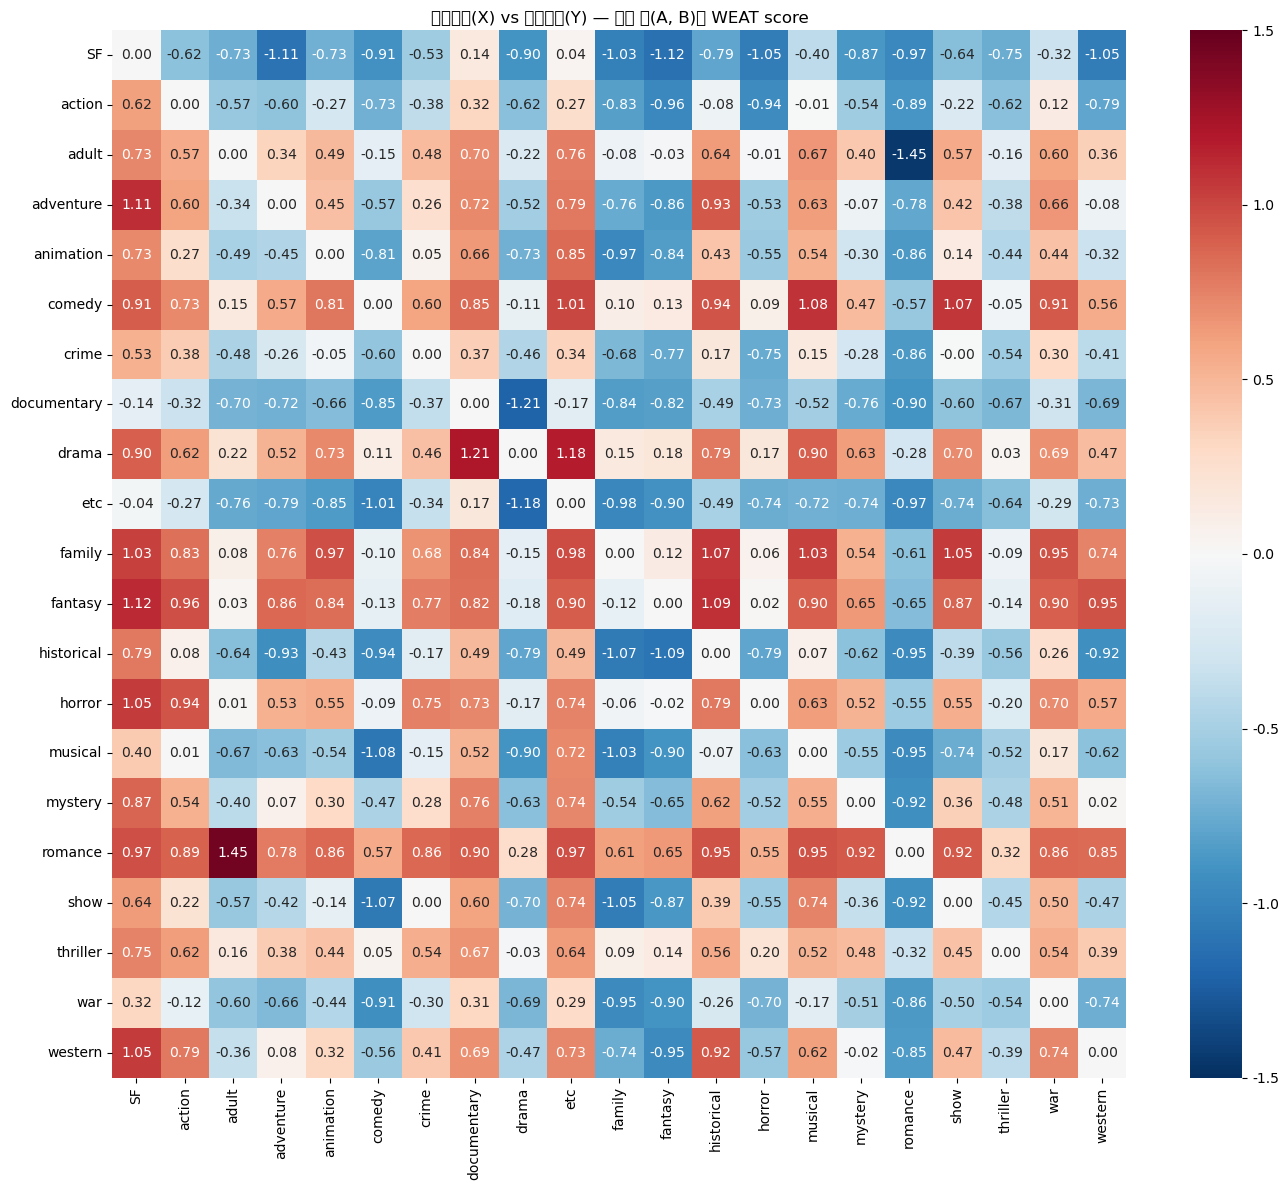

편향 큰 상위 쌍:
adult vs romance: -1.453
romance vs adult: 1.453
documentary vs drama: -1.210
drama vs documentary: 1.210
drama vs etc: 1.179
etc vs drama: -1.179
fantasy vs SF: 1.125
SF vs fantasy: -1.125
adventure vs SF: 1.105
SF vs adventure: -1.105


In [11]:
# %% Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(matrix, xticklabels=genre_name, yticklabels=genre_name,
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1.5, vmax=1.5)
plt.title('예술영화(X) vs 일반영화(Y) — 장르 쌍(A, B)별 WEAT score')
plt.tight_layout()
plt.show()
 
# 해석: matrix[i][j] > 0 → 예술영화는 장르 i와, 일반영화는 장르 j와 가까움
#       |score|가 1.0 이상인 쌍이 편향이 두드러지는 케이스
print('편향 큰 상위 쌍:')
idx = np.dstack(np.unravel_index(np.argsort(-np.abs(matrix), axis=None), matrix.shape))[0]
for i, j in idx[:10]:
    print(f'{genre_name[i]} vs {genre_name[j]}: {matrix[i][j]:.3f}')

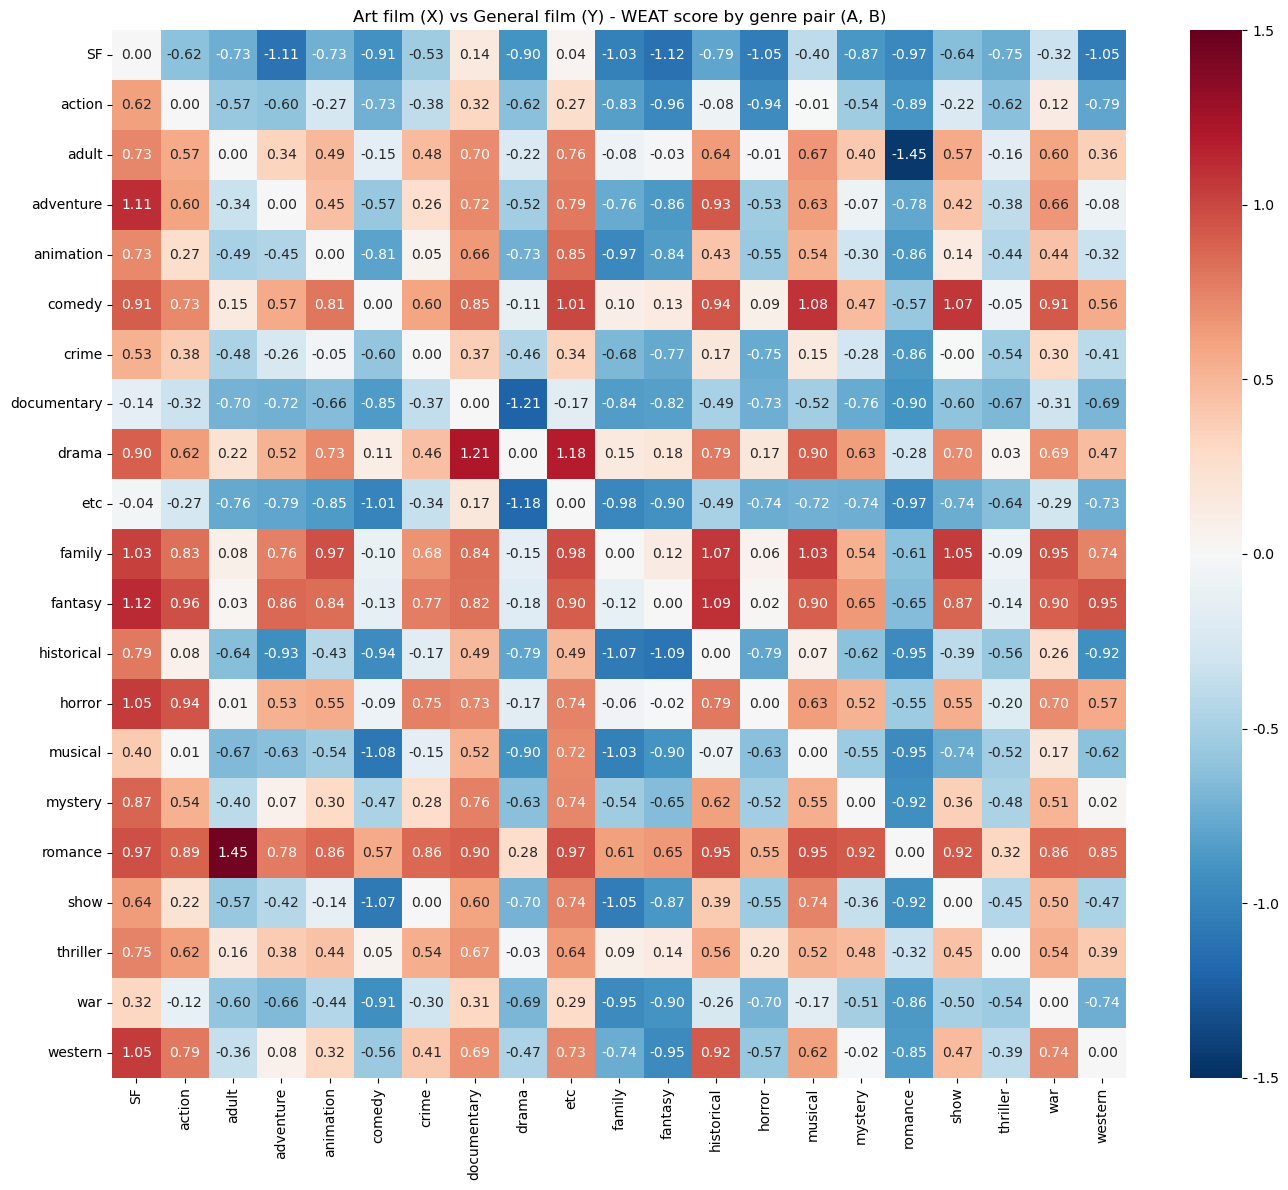

In [12]:
plt.rc('font', family='DejaVu Sans')   # 기본 폰트로 복구

plt.figure(figsize=(14, 12))
sns.heatmap(matrix, xticklabels=genre_name, yticklabels=genre_name,
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1.5, vmax=1.5)
plt.title('Art film (X) vs General film (Y) - WEAT score by genre pair (A, B)')
plt.tight_layout()
plt.show()